# Lake Erie SFINCS Tutorial - bring your own DEM

This notebook builds and runs a [SFINCS](https://sfincs.readthedocs.io)
model for a spot on the Ohio shore of Lake Erie (Fairport Harbor), forced at
the open boundary by NOAA's **Lake Erie Operational Forecast System
(LEOFS)** - the FVCOM model behind GLOFS.

It follows the same create and run phases as the
[Lavaca Bay notebook](lavaca.ipynb), and differs from it in three key ways:

| | Lavaca Bay | Lake Erie |
| --- | --- | --- |
| Boundary forcing | `stofs` (ocean) | `glofs` + `glofs_model: leofs` (FVCOM) |
| Elevation | auto-fetched `noaa_3m` + `gebco_15arcs` | **hand-downloaded DEM + your own data catalog** |
| Vertical datum | NAVD88, tides about MSL | Lake Erie **Low Water Datum** (173.5 m IGLD85) |

Rather than using the built-in topobathy options, this tutorial shows how
to use your own data in the model building process.

## The domain files

This example runs end to end as shipped - a working Fairport Harbor domain is
included, so you can execute every cell before changing anything. The geometry
lives in `docs/examples/lake-erie_sfincs/` next to the configs:

| File | Shipped? | What it is |
| --- | --- | --- |
| `sfincs_aoi_lake_erie.geojson` | **yes** | model domain polygon, 425 km² at Fairport Harbor |
| `discharge_nwm.geojson` | **yes** | 4 NWM flowpaths - keyed by an `ID` column |
| `refine.geojson` | no | optional sub-area to resolve finer quadtree levels; `grid.refinement` is commented out in `create.yaml` unless you add one |

**To model somewhere else on the lake, replace those two files** and re-run
from section 2, which measures whatever geometry it finds against the DEM and
prints the `grid` and `mask` settings to paste into `create.yaml` - so those
numbers come from your domain rather than from the shipped one.

The two sections below show how the shipped files were made, which is also the
recipe for making your own.

### Working in your own copy

Every path in `create.yaml`, `run.yaml` and `dem_catalog.yml` is relative to
the example folder, and everything the example downloads lands in
`downloads/` inside it, so the folder can be copied and run anywhere:

```bash
cp -r docs/examples/lake-erie_sfincs ~/my_erie_run
LAKE_ERIE_DIR=~/my_erie_run jupyter lab docs/examples/notebooks/lake_erie.ipynb
```

Three things land under `downloads/`: `dem/` (~70 MB, step 1b,)
 `grid/` (ESA WorldCover clips written by `create`), and `forcing/`
(GB-scale GLOFS and NWM data written by `run`). If you already have a shared
forcing cache, point `paths.raw_download_dir` at it and leave the other two
alone.

### Drawing the AOI

The shipped domain was created with the `nwm_coastal` QGIS plugin's polygon
sketcher - the orange rectangle below, on the Lake Erie shore at Fairport
Harbor, Ohio. Use the same workflow to draw your own.

![AOI sketched over Lake Erie with CO-OPS gauges](../images/Lake_Erie_SFINCS_SketcherPoly.jpg)

Two things to note from how it is drawn:

- **It straddles the shoreline.** The lakeward half gives the LEOFS boundary
  somewhere to attach to; the landward half is the floodplain you
  actually want results in. An AOI entirely offshore has nothing to inundate,
  and one entirely onshore has no boundary.
- **It contains a gauge.** The stars are NOAA CO-OPS stations; this domain
  captures **9063053 (Fairport Harbor)**, which is what the pipeline validates
  against later. Cleveland (9063063) sits just west of the box - if you want a
  particular gauge in the comparison, make sure the polygon covers it.

After drawing the polygon, make sure to select "Union with NHF Divides" and then
save.

### Selecting the flowpaths

The plugin loads the National Hydrofabric, so the flowpaths (blue), their
nexus points (green) and the catchment divides can be seen while selecting.
Because this notebook runs a historical case, the flowpaths override option
was chosen when loading the map. The NWM_v3_hydrofabric.gdb was chosen
as the override, with nwm_reaches_conus as the name. After selecting the
flowpaths entering the domain, they are exported to `discharge_nwm.geojson`.

![Merged divides polygon with the selected discharge flowpaths](../images/Lake_Erie_SFINCS_MergedPoly_SelectedFlowpaths.jpg)

Select the reach that **crosses the AOI boundary**, since that crossing point
is where the pipeline injects the discharge.

## Setup

Every path below is relative to the example folder, so the notebook starts by
moving into it. It looks in three places, in order: `$LAKE_ERIE_DIR`, the
current directory, then a `lake-erie_sfincs` sibling. That covers running from
`docs/examples/notebooks/` as shipped, and running from inside a copy of the
folder you made somewhere else.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

candidates = [Path.cwd(), Path.cwd().parent / "lake-erie_sfincs"]
if os.environ.get("LAKE_ERIE_DIR"):
    candidates.insert(0, Path(os.environ["LAKE_ERIE_DIR"]))

for candidate in candidates:
    if (candidate / "create.yaml").exists():
        example_dir = candidate.resolve()
        break
else:
    searched = "\n  ".join(str(c) for c in candidates)
    raise FileNotFoundError(
        f"Could not find the example folder (no create.yaml in):\n  {searched}\n"
        "Set LAKE_ERIE_DIR to point at your copy."
    )

os.chdir(example_dir)
print(f"working in {example_dir}")

working in docs/examples/lake-erie_sfincs


## 1. The DEM, step by step

### 1a. Pick a source

We use NCEI's
[Bathymetry of Lake Erie and Lake Saint Clair](https://www.ncei.noaa.gov/products/great-lakes-bathymetry)
- a seamless 3 arc-second (~70 x 90 m) topobathy grid covering the whole
lake, distributed as a 22 MB tarball.

Its ~70 m resolution is the ceiling on what the model can resolve on land,
which is why `create.yaml` uses a uniform 256 m grid: refining below the DEM
pixel would invent detail the data does not have. Add a `refine.geojson` and
re-enable `grid.refinement` if you bring a finer DEM.

Other candidates, if you want more detail:

- **NOAA OCM Coastal DEM: Lake Erie** - ~3 m lidar + sonar topobathy,
  NAVD88, via the [Data Access Viewer](https://coast.noaa.gov/dataviewer/).
  Best resolution, but it is an interactive order rather than a direct
  download, and it is NAVD88 rather than LWD.
- **USGS Lake Erie seamless topobathymetric DEM**
  ([doi:10.5066/P1DA6L6U](https://doi.org/10.5066/P1DA6L6U)) - lidar plus
  USACE dredge surveys.
- **USGS 3DEP** 1 m / 10 m - land only, no lake bed.

### 1b. Download and unpack

The example catalog provided with the demo expects the GeoTIFF at
`downloads/dem/erie_lld.tif`, relative to the example folder.

In [2]:
import tarfile
import urllib.request

DEM_URL = "https://www.ngdc.noaa.gov/mgg/greatlakes/erie/data/geotiff/erie_lld.geotiff.tar.gz"
dem_dir = Path("./downloads/dem")
dem_path = dem_dir / "erie_lld.tif"

if dem_path.exists():
    print(f"already present: {dem_path} ({dem_path.stat().st_size / 1e6:.1f} MB)")
else:
    dem_dir.mkdir(parents=True, exist_ok=True)
    tarball = dem_dir / "erie_lld.geotiff.tar.gz"
    print(f"downloading {DEM_URL}")
    urllib.request.urlretrieve(DEM_URL, tarball)
    with tarfile.open(tarball) as tar:
        for member in tar.getmembers():
            if member.name.endswith((".tif", ".prj", ".tfw")):
                member.name = Path(member.name).name  # flatten erie_lld/ prefix
                tar.extract(member, dem_dir)
    tarball.unlink()
    print(f"extracted: {sorted(p.name for p in dem_dir.iterdir())}")

already present: downloads/dem/erie_lld.tif (69.2 MB)


### 1c. Inspect it before trusting it

Three things decide whether a DEM can be used as-is: its CRS, its NoData
value, and its **vertical datum**. The first two are in the file; the third
is not, so it has to be inferred and cross-checked against something you
know. This reads the whole lake - no AOI needed yet.

In [3]:
import numpy as np
import rasterio

with rasterio.open(dem_path) as src:
    print(f"crs        : {src.crs.to_string()}")
    print(f"size       : {src.width} x {src.height}")
    print(f"pixel size : {src.res[0]:.8f} deg  (~{src.res[0] * 111e3 * 0.74:.0f} m in x at 42N)")
    print(f"dtype      : {src.dtypes[0]}")
    print(f"nodata     : {src.nodata}")
    print(f"bounds     : {src.bounds}")
    band = src.read(1, out_shape=(src.height // 4, src.width // 4))  # decimated overview

values = band[band > -9000]
print(f"\nelevation  : {values.min():+.1f} .. {values.max():+.1f} m")

crs        : EPSG:4269
size       : 7201 x 2401
pixel size : 0.00083333 deg  (~68 m in x at 42N)
dtype      : float32
nodata     : -9999.0
bounds     : BoundingBox(left=-84.00041666666665, bottom=40.99958333333335, right=-77.99958333357336, top=43.000416666586645)

elevation  : -62.5 .. +602.5 m


The datum is the lake's **Low Water Datum (173.5 m IGLD85)**,
which is what the NCEI product description says and, conveniently, the same
datum GLOFS publishes water levels in, so the forcing needs no datum shift.

Rendered, the seamless topobathy looks like this - lake bed in blues, land in
greens and tans, with this example's AOI in red.

![Lake Erie topobathy under the AOI](../images/Lake_Erie_Topobathy.jpg)

### 1d. Write the HydroMT data catalog

A dataset with `source: null` in `create.yaml` is looked up by name in the
HydroMT data catalogs listed under `data_catalog.data_libs`. `dem_catalog.yml`
is that catalog, and it ships with this example:

```yaml
meta:
  version: v1.0.0
  name: lake_erie_dem
  hydromt_version: '>1.0a,<2'

erie_lld:
  data_type: RasterDataset
  uri: downloads/dem/erie_lld.tif
  driver:
    name: rasterio
  metadata:
    category: topography
    crs: 4269
  data_adapter:
    rename:
      erie_lld: elevtn
```

Four things to get right when you adapt this to your own DEM:

- **`uri`** is resolved relative to the catalog file, so keep the catalog
  and the raster in a fixed relationship to each other.
- **`data_type: RasterDataset`** with **`driver: {name: rasterio}`** for any
  GeoTIFF; use `driver: {name: raster_xarray}` for NetCDF.
- **`metadata.crs`** is only needed when the file itself lacks a CRS, but
  stating it is good practice.
- **`data_adapter.rename`** must map the variable HydroMT reads to
  **`elevtn`**, which is the name HydroMT-SFINCS looks for. For a
  single-band GeoTIFF, HydroMT names the variable after the *catalog entry
  key* - `erie_lld` here - so the mapping is `erie_lld: elevtn`. If this is
  wrong the elevation stage will fail with a missing-variable error.

The cell below reads the dataset through the catalog exactly as the pipeline will.

In [4]:
from hydromt import DataCatalog

catalog = DataCatalog(data_libs=["./dem_catalog.yml"])
da = catalog.get_rasterdataset("erie_lld", bbox=[-83.6, 41.55, -82.9, 41.85])
assert da.name == "elevtn", f"expected variable 'elevtn', got {da.name!r} - fix data_adapter.rename"
print(da)

2026-09-27 23:32:47,987 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from ./dem_catalog.yml


2026-09-27 23:32:48,030 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading erie_lld RasterDataset data from docs/examples/lake-erie_sfincs/downloads/dem/erie_lld.tif


<xarray.DataArray 'elevtn' (y: 360, x: 840)> Size: 1MB
dask.array<getitem, shape=(360, 840), dtype=float32, chunksize=(360, 840), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 3kB 41.85 41.85 41.85 41.85 ... 41.55 41.55 41.55
  * x            (x) float64 7kB -83.6 -83.6 -83.6 -83.6 ... -82.9 -82.9 -82.9
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -9999.0
    source_file:    erie_lld.tif


## 2. Measure your AOI against the DEM

This reads the AOI in the example folder and reports what the DEM says
about it: how big the domain is, which UTM zone it lands in, and how deep
the bed goes in the LWD datum the DEM turned out to use. Nothing here is a
pass/fail check, it is a look before you build.

In [5]:
import geopandas as gpd

aoi_candidates = sorted(Path().glob("*aoi*.geojson"))
aoi_path = aoi_candidates[0] if aoi_candidates else Path("./aoi.geojson")
if not aoi_path.exists():
    raise FileNotFoundError(
        f"No {aoi_path.resolve()}. Digitize your model domain and save it there "
        '(see "The domain files" at the top of this notebook), then re-run from here.'
    )

aoi = gpd.read_file(aoi_path).to_crs(4326)
refine = (
    gpd.read_file("./refine.geojson").to_crs(4326) if Path("./refine.geojson").exists() else None
)
flow_path = Path("./discharge_nwm.geojson")
flowlines = gpd.read_file(flow_path) if flow_path.exists() else None

utm = aoi.estimate_utm_crs()
area_km2 = aoi.to_crs(utm).area.sum() / 1e6
print(f"aoi       : {len(aoi)} feature(s), {area_km2:,.0f} km^2")
print(f"bounds    : {np.round(aoi.total_bounds, 4)}")
print(f"utm zone  : {utm.to_string()}  <- what grid.crs 'utm' will resolve to")
if refine is not None:
    overlap_m2 = refine.to_crs(utm).intersection(aoi.to_crs(utm).union_all()).area.sum()
    print(
        f"refine    : {len(refine)} feature(s), {overlap_m2 / 1e6:,.0f} km^2 of it inside the AOI"
    )
else:
    print("refine    : none - drop grid.refinement from create.yaml")
if flowlines is not None:
    cols = [c for c in flowlines.columns if c != "geometry"]
    print(f"flowpaths : {len(flowlines)} feature(s); columns {cols}")
else:
    print("flowpaths : none - drop river_discharge from create.yaml")

aoi       : 1 feature(s), 425 km^2
bounds    : [-81.4698  41.6197 -81.0916  41.8822]
utm zone  : EPSG:32617  <- what grid.crs 'utm' will resolve to
refine    : none - drop grid.refinement from create.yaml
flowpaths : 4 feature(s); columns ['OBJECTID', 'ID', 'Shape_Length']


### What the DEM says inside your AOI

In [6]:
clipped = catalog.get_rasterdataset("erie_lld", bbox=list(aoi.total_bounds)).load()
clipped = clipped.where(clipped > -9000)  # drop NoData before any statistic
inside = clipped.values[np.isfinite(clipped.values)]

print(f"elevation : {inside.min():+.2f} .. {inside.max():+.2f} m (LWD)")
print(f"below LWD : {(inside < 0).mean():.0%} of the AOI bounding box")
wet = inside[inside < 0]
if wet.size:
    print("\nsubmerged part, m relative to LWD:")
    for pct in (5, 25, 50, 75, 95):
        print(f"  {pct:>2}% of submerged cells are deeper than {np.percentile(wet, pct):+.2f}")
else:
    print("\nno submerged cells - this AOI is entirely above low water, which cannot be")
    print("right for a lake model; extend it lakeward before going on")

2026-09-27 23:32:48,352 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading erie_lld RasterDataset data from docs/examples/lake-erie_sfincs/downloads/dem/erie_lld.tif


elevation : -21.50 .. +216.50 m (LWD)
below LWD : 51% of the AOI bounding box

submerged part, m relative to LWD:
   5% of submerged cells are deeper than -20.90
  25% of submerged cells are deeper than -19.10
  50% of submerged cells are deeper than -16.50
  75% of submerged cells are deeper than -11.70
  95% of submerged cells are deeper than -5.20


Text(0.5, 1.0, 'DEM over the AOI bounding box')

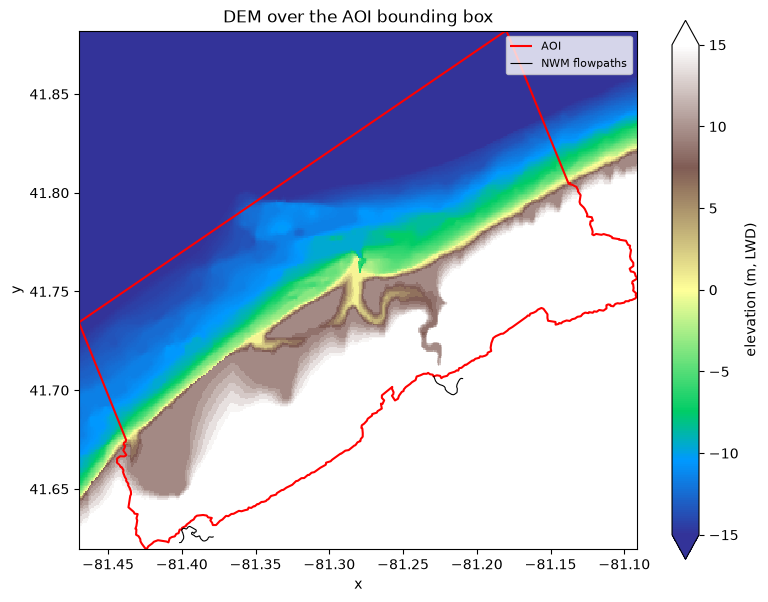

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))
clipped.plot(ax=ax, cmap="terrain", vmin=-15, vmax=15, cbar_kwargs={"label": "elevation (m, LWD)"})
aoi.boundary.plot(ax=ax, color="red", linewidth=1.5, label="AOI")
if refine is not None:
    refine.boundary.plot(ax=ax, color="magenta", linewidth=1.2, label="refine")
if flowlines is not None and len(flowlines):
    flowlines.to_crs(4326).plot(ax=ax, color="black", linewidth=0.8, label="NWM flowpaths")
ax.legend(loc="upper right", fontsize=8)
ax.set_title("DEM over the AOI bounding box")

## 3. Create the SFINCS model

From here on this is the Lavaca workflow. The only differences in the create
config are the `data_catalog` block, the `source: null` elevation entry, and
mask thresholds expressed in LWD instead of NAVD88.

The `grid` and `mask` values below, and the same ones in `create.yaml`, are
what section 2 derived for a 425 km^2 Fairport Harbor domain. Replace
them with what section 2 printed for your AOI.

In [8]:
from coastal_calibration import SfincsCreateConfig, SfincsCreator, configure_logger

configure_logger(level="INFO")

create_config = SfincsCreateConfig.from_dict(
    {
        "aoi": "./sfincs_aoi_lake_erie.geojson",
        "output_dir": "./sfincs_fh_lake_erie",
        "download_dir": "./downloads/grid",
        "grid": {
            "resolution": 256,
            "crs": "utm",
            "rotated": False,
            # add a refine.geojson and re-enable to resolve the river mouths finer
            "refinement": [],
        },
        "data_catalog": {"data_libs": ["./dem_catalog.yml"]},
        "elevation": {
            "datasets": [
                {"name": "erie_lld", "zmin": -20000, "source": None},
            ],
            "buffer_cells": 1,
        },
        "mask": {
            # Clip to the AOI.
            "include_polygon": "./sfincs_aoi_lake_erie.geojson",
            "boundary_zmax": -1.0,
            "reset_bounds": True,
            "keep_largest_only": True,
        },
        "subgrid": {
            "nr_subgrid_pixels": 4,
            "lulc_dataset": "esa_worldcover",
            "manning_land": 0.04,
            "manning_sea": 0.02,
        },
        # Drop this block if you have no flowpaths yet.
        "river_discharge": {
            "flowlines": "./discharge_nwm.geojson",
            "nwm_id_column": "ID",
        },
        "add_noaa_gages": True,
    }
)

In [9]:
creator = SfincsCreator(create_config)
result = creator.run()
if not result.success:
    raise RuntimeError(f"Model creation failed at stage '{result.stages_failed}': {result.errors}")
print(result)

Coastal Calibration Workflow                                                    


Start Time: 2026-09-28 03:32:49                                                 


----------------------------------------                                        


Stage: create_grid                                                              


Start Time: 2026-09-28 03:32:49                                                 


...

  [✓] create_discharge: 0s                                                      


  [✓] create_subgrid: 17s                                                       


  [✓] create_obs: 0s                                                            


  [✓] create_write: 0s                                                          


WorkflowResult: SUCCESS
  Start:     2026-09-28 03:32:49
  End:       2026-09-28 03:33:09
  Duration:  19s
  Completed: create_grid, create_fetch_data, create_elevation, create_mask, create_boundary, create_discharge, create_subgrid, create_obs, create_write


### Inspect the created model

In [10]:
output = Path("./sfincs_fh_lake_erie")
assert output.exists(), (
    f"Output directory not found: {output.resolve()} - run the create step first."
)

for f in sorted(output.iterdir()):
    if f.name.startswith(".") or f.suffix == ".log":
        continue
    size = f.stat().st_size
    label = f"{size / 1e6:.1f} MB" if size > 1e6 else f"{size / 1e3:.1f} KB"
    print(f"  {f.name:<30s} {label}")

  create_progress.json           2.2 KB
  create_result.json             1.4 KB
  gis                            4.1 KB
  obs_station_map.json           0.1 KB
  sfincs.bnd                     0.4 KB
  sfincs.bzs                     0.2 KB
  sfincs.inp                     1.0 KB
  sfincs.nc                      2.7 MB
  sfincs.obs                     0.0 KB
  sfincs_nwm.src                 0.1 KB
  sfincs_subgrid.nc              4.4 MB
  subgrid                        4.1 KB


### Where the boundary and source points landed

These are the points SFINCS will actually force: the LEOFS water-level
boundary, the river inflows snapped from your flowpaths, and the CO-OPS gauge
used for validation. Read straight out of the model directory, in the model's
own CRS.

The boundary points should sit along the lakeward edge, the discharge points
where the rivers cross into the domain, and the gauge in open water.

Text(0.5, 1.0, 'forcing points written by create (EPSG:32617)')

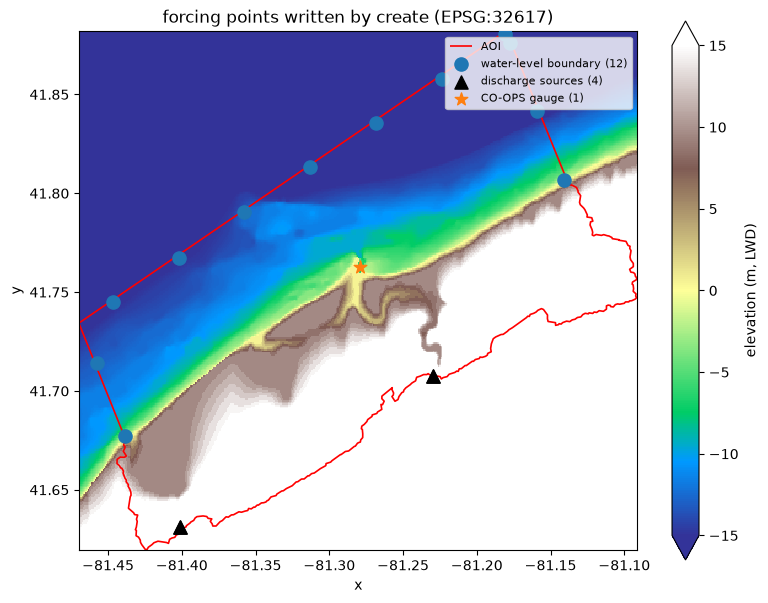

In [11]:
from pyproj import Transformer


def _read_points(path: Path) -> tuple[list[float], list[float]]:
    """Read the leading x, y columns of a SFINCS .bnd / .src / .obs file."""
    if not path.exists():
        return [], []
    xs, ys = [], []
    for line in path.read_text().splitlines():
        parts = line.split()
        if len(parts) >= 2:
            xs.append(float(parts[0]))
            ys.append(float(parts[1]))
    return xs, ys


model_epsg = next(
    (
        int(ln.split("=")[1])
        for ln in (output / "sfincs.inp").read_text().splitlines()
        if ln.strip().startswith("epsg")
    ),
    32617,
)
to_wgs = Transformer.from_crs(model_epsg, 4326, always_xy=True)

fig, ax = plt.subplots(figsize=(9, 7))
clipped.plot(ax=ax, cmap="terrain", vmin=-15, vmax=15, cbar_kwargs={"label": "elevation (m, LWD)"})
aoi.boundary.plot(ax=ax, color="red", linewidth=1.2, label="AOI")

for fname, colour, marker, label in [
    ("sfincs.bnd", "tab:blue", "o", "water-level boundary"),
    ("sfincs_nwm.src", "black", "^", "discharge sources"),
    ("sfincs.obs", "tab:orange", "*", "CO-OPS gauge"),
]:
    xs, ys = _read_points(output / fname)
    if xs:
        lon, lat = to_wgs.transform(xs, ys)
        ax.scatter(lon, lat, c=colour, marker=marker, s=90, zorder=5, label=f"{label} ({len(xs)})")

ax.legend(loc="upper right", fontsize=8)
ax.set_title(f"forcing points written by create (EPSG:{model_epsg})")

## 4. Run the simulation pipeline

### LEOFS boundary forcing

`boundary.source: glofs` with `glofs_model: leofs` replaces STOFS. Two
constraints come with it:

- `simulation.coastal_domain` must be `greatlakes`, and that domain accepts
  no other boundary source - the tidal atlases and STOFS do not cover the
  lakes. Either setting without the other is rejected at config load.
- Only **nowcast** files are read, from NCEI's archive, so the run window
  must be in the past (2016 onward, depending on the lake).

The download stage reads only `time`, `lon`, `lat` and `zeta` out of each
hourly FVCOM file - those files run up to ~180 MB an hour - and caches the
slices under `downloads/forcing/coastal/glofs/leofs/`. If LEOFS changed its
unstructured grid inside your window, the stage stops and tells you where;
split the run at that time.

Meteorology still comes from NWM (`meteo_source: nwm_ana`), whose CONUS
domain covers the lakes.

### Why these overrides

A few `run_param_overrides` are specific to running SFINCS on a lake surface
174 m above sea level:

| Override | Default | Why it is wrong here |
| --- | --- | --- |
| `zsini` = `0.90` | `0` | Initial water level, in mesh datum. On LWD, 0 means "exactly at low water" - usable, but Erie typically sits a few decimetres above LWD. Set it from the CO-OPS Fairport Harbor (9063053) record at your start time. On an *absolute* IGLD85 mesh the default would start the model dry. |
| `latitude` = `41.75` | `0` | A projected grid carries no latitude, so Coriolis would be computed at the equator. |

The mesh and GLOFS share the LWD datum, so `forcing_to_mesh_offset_m` carries
no datum shift; it is `-0.1` purely to correct a LEOFS high bias of about
that size. If you rebuild the mesh from an absolute-elevation DEM (the NOAA
OCM 3 m product, say), add `173.5` to it and raise `zsini` accordingly.

In [12]:
from coastal_calibration import CoastalCalibConfig, CoastalCalibRunner

run_config = CoastalCalibConfig.from_dict(
    {
        "model": "sfincs",
        "simulation": {
            "start_date": "2026-08-15 00:00:00",
            "duration_hours": 12,
            "coastal_domain": "greatlakes",
            "meteo_source": "nwm_ana",
        },
        "boundary": {"source": "glofs", "glofs_model": "leofs"},
        "paths": {
            "work_dir": "./run",
            "raw_download_dir": "./downloads/forcing",
        },
        "download": {"enabled": True},
        "model_config": {
            "prebuilt_dir": "./sfincs_fh_lake_erie",
            "discharge_locations_file": "./sfincs_fh_lake_erie/sfincs_nwm.src",
            "merge_discharge": True,
            "forcing_to_mesh_offset_m": -0.1,  # LEOFS reads ~0.1 m high
            "vdatum_mesh_to_msl_m": 173.5,  # IGLD observations -> the LWD mesh
            "include_precip": True,
            "include_wind": True,
            "include_pressure": True,
            "floodmap_dem": "./downloads/dem/erie_lld.tif",
            "run_param_overrides": {
                "tspinup": 10800,
                "advection": 0,
                "viscosity": 0,
                "nuvisc": 0.01,
                "cdnrb": 3,
                "cdwnd": [0.0, 28.0, 50.0],
                "cdval": [0.001, 0.0025, 0.0025],
                "zsini": 0.90,
                "latitude": 41.75,
            },
        },
    }
)

In [13]:
runner = CoastalCalibRunner(run_config)
result = runner.run()
if not result.success:
    raise RuntimeError(f"Model run failed at stage '{result.stages_failed}': {result.errors}")
print(result)

Coastal Calibration Workflow                                                    


Start Time: 2026-09-28 03:33:09                                                 


----------------------------------------                                        


Cleaned generated files from                                                    
docs/examples/lake-erie_sfincs/run            


Stage: download                                                                 


...

  [✓] sfincs_write: 0s                                                          


  [✓] sfincs_run: 3s                                                            


  [✓] sfincs_floodmap: 9s                                                       


  [✓] sfincs_plot: 1s                                                           


WorkflowResult: SUCCESS
  Start:     2026-09-28 03:33:09
  End:       2026-09-28 03:33:31
  Duration:  21s
  Completed: download, sfincs_symlinks, sfincs_data_catalog, sfincs_init, sfincs_timing, sfincs_forcing, sfincs_discharge, sfincs_precip, sfincs_wind, sfincs_pressure, sfincs_write, sfincs_run, sfincs_floodmap, sfincs_plot


## 5. Gauge comparison

With `add_noaa_gages: true` the pipeline compares against NOAA CO-OPS lake
gauges - just Fairport Harbor (9063053) for this AOI. Lake gauges publish
observations but no tide
predictions and no MSL or MLLW, so observations are fetched in **IGLD** and
shifted onto the mesh datum by `vdatum_mesh_to_msl_m`: the comparison is
made in the mesh datum, not MSL as on the coast.

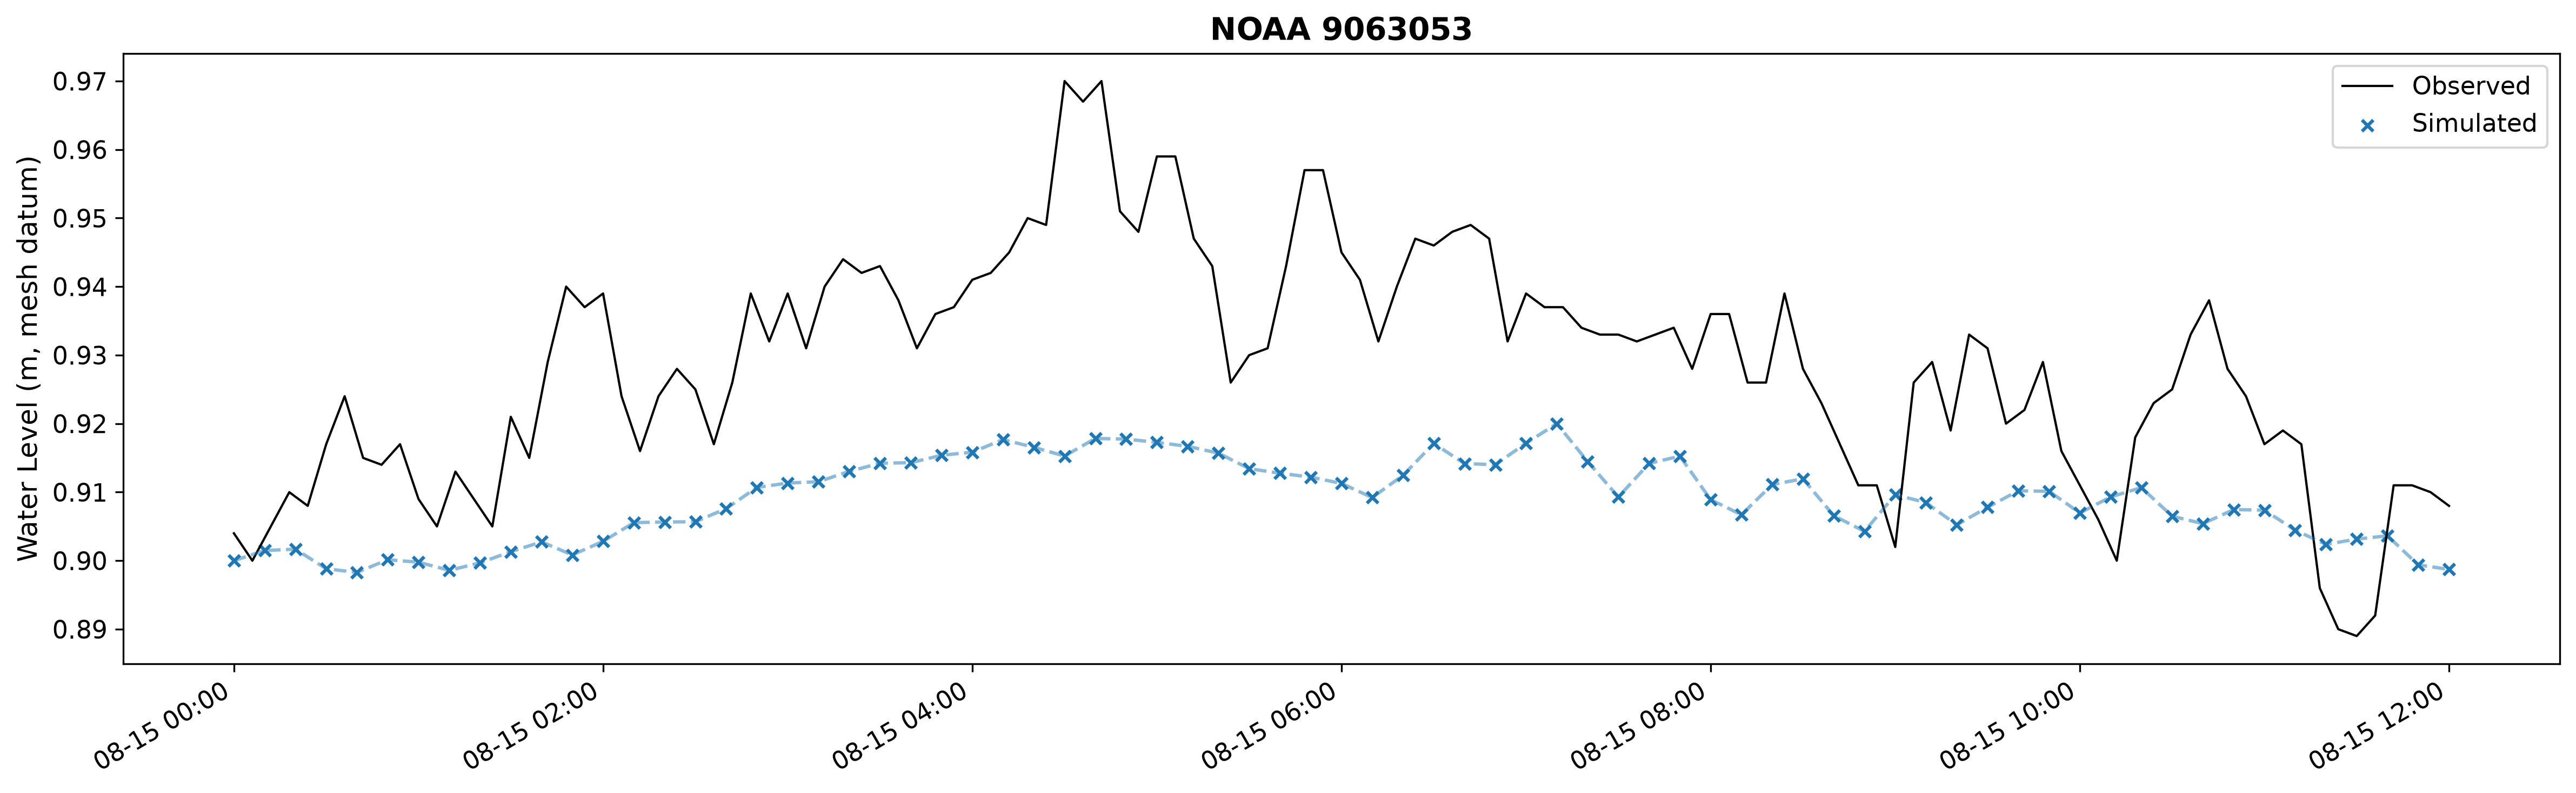

In [14]:
figs_dir = Path("run/sfincs_model/figs")
plots = sorted(figs_dir.glob("stations_comparison_*.png")) if figs_dir.exists() else []


def _in_notebook() -> bool:
    """Return True only under IPython, so this cell also works as a script."""
    try:
        from IPython import get_ipython
    except ImportError:
        return False
    return get_ipython() is not None


if not plots:
    print(f"No comparison plots in {figs_dir} - run the pipeline first.")
elif _in_notebook():
    from IPython.display import Image, display

    for png in plots:
        display(Image(filename=str(png), width=800))
else:
    print("comparison plots written:")
    for png in plots:
        print(f"  {png}")

## Summary

1. Downloaded a Great Lakes topobathy DEM by hand, checked its CRS, NoData
   and vertical datum, and registered it in `dem_catalog.yml`.
2. Used the `create` workflow to build the model.
4. Ran the model with LEOFS (FVCOM) boundary forcing and the
   elevated-domain `run_param_overrides` (`zsini`, `latitude`), then compared
   against CO-OPS lake gauge.

### Adapting this to another lake

Swap `glofs_model` (`lmhofs` for Michigan-Huron, `loofs` for Ontario,
`lsofs` for Superior), download that lake's grid from the same NCEI
product, and change the LWD constants: Michigan-Huron 176.0 m, Ontario
74.2 m, Superior 183.2 m (IGLD85). Everything else carries over.